# 06: Hull-White one-factor model — calibration and simulation

## Objective

This notebook demonstrates the one-factor Hull-White short-rate model in
`yieldcurve.models.hullwhite`. It is an educational example, not a
production pricing or risk system. Concretely, we:

- state the model and its analytic results: the conditional Gaussian
  distribution of the short rate, the complete affine zero-coupon bond
  formula, and the model-implied probability of negative rates;
- verify that a Hull-White instance reproduces the input discount curve
  (an identity of the construction, kept as a regression check);
- sample short-rate paths with the exact Gaussian transition and compare
  simulated moments with the analytic conditional moments, printing both;
- approximate path discount factors by monthly trapezoid quadrature and
  compare them with the exact analytic bond price, printing both;
- fit $(a, \sigma)$ to the packaged *illustrative* swaption volatility grid
  (a constructed grid, not market data) and report the full optimizer and
  identification diagnostics;
- compute the negative-rate probability from the conditional model
  distribution of the fitted parameters.

The model admits closed-form bond and European swaption prices, which is
what makes a two-parameter one-factor example tractable end to end. The
limitations that come with that tractability are documented in
`docs/hull-white-limitations.md` and restated in the Limitations section.

## Data

**Snapshot date:** 24 July 2026. The one committed, read-only snapshot
ships as packaged resources under `yieldcurve.data` (loaded via
`importlib.resources`): no network access, no `data/` directory, no
checkout-path fallback.

**Discount curve:** the USD OIS curve is bootstrapped from the snapshot's
OIS swap quotes (`usd_ois_swaps.csv`) with the canonical log-linear
discount-factor bootstrap. It is the initial term structure the Hull-White
drift $\theta(t)$ is constructed to match exactly.

**Swaption volatilities:** the snapshot contains no market swaption
volatility data (CME cleared-swaption settlement files require a CME
Information License Agreement and are not redistributable here). The
notebook calibrates to the packaged **illustrative** grid
(`illustrative_swaption_vols.csv`, classified *illustrative* in the
snapshot manifest): 28 ATM payer swaptions on 7 expiries (0.5y to 10y) by
4 swap tenors (1y to 10y), normal volatilities generated by a
deterministic formula in `scripts/build_illustrative_vols.py`. The shape
is market-plausible, but the grid is constructed, not a fit to any traded
price. Every volatility-related number below is therefore an illustration
of the calibration workflow on this constructed grid, not a market
calibration.

## Theory

### The model

The Hull-White (1993) short-rate model extends Vasicek by making the mean
reversion level a deterministic function of time, so that today's term
structure is reproduced exactly. Under the risk-neutral measure:

$$\mathrm{d}r(t) = \left[\theta(t) - a \cdot r(t)\right] \mathrm{d}t + \sigma \, \mathrm{d}W(t)$$

with $a > 0$ the mean-reversion speed, $\sigma > 0$ the volatility, and

$$\theta(t) = \frac{\partial f^M(0,t)}{\partial t} + a f^M(0,t)
  + \frac{\sigma^2}{2a}\left(1 - e^{-2at}\right)$$

chosen so that the model matches the initial market forward curve
$f^M(0,\cdot)$ and discount curve $P^M(0,\cdot)$ by construction.

**The implementation never evaluates $\theta$.** It contains the second
derivative of the discount curve, which is noise on a bootstrapped curve
whose instantaneous forward is only $C^0$ (continuous, with kinks at the
knots). The analytic bond price needs only $P^M(0,\cdot)$ and
$f^M(0,\cdot)$ — first derivatives — and exact simulation needs only the
same, so the implementation routes around $\theta$ entirely.

### Conditional distribution

The SDE is linear in $r$, so the transition is Gaussian. With

$$\alpha(t) = f^M(0,t) + \frac{\sigma^2}{2a^2}\left(1 - e^{-at}\right)^2$$

the model integrates to

$$r(s) = r(t)e^{-a(s-t)} + \alpha(s) - \alpha(t)e^{-a(s-t)}
  + \sigma\int_t^s e^{-a(s-u)}\,\mathrm{d}W(u),$$

so $r(s) \mid \mathcal{F}_t$ is normal with

$$E\{r(s)\mid\mathcal{F}_t\} = r(t)e^{-a(s-t)} + \alpha(s) - \alpha(t)e^{-a(s-t)},
\qquad
\operatorname{Var}\{r(s)\mid\mathcal{F}_t\} = \frac{\sigma^2}{2a}\left[1 - e^{-2a(s-t)}\right].$$  # noqa: E501

Since $r(0) = \alpha(0) = f^M(0,0)$, the unconditional mean collapses to
$E[r(t)] = \alpha(t)$. These are exactly the `conditional_mean` and
`conditional_sd` methods of `HullWhite`.

### The complete affine bond formula

A zero-coupon bond price is exponential-affine in the short rate:

$$P(t,T) = A(t,T)\,e^{-B(t,T)\,r(t)}, \qquad
  B(t,T) = \frac{1 - e^{-a(T-t)}}{a},$$

$$A(t,T) = \frac{P^M(0,T)}{P^M(0,t)}
  \exp\left\{B(t,T)\,f^M(0,t)
    - \frac{\sigma^2}{4a}\left(1 - e^{-2at}\right)B(t,T)^2\right\}.$$

The first factor of $A(t,T)$ is the market discount ratio, the second the
convexity-adjusted forward term, the third the variance correction. The
state term $e^{-B(t,T)r(t)}$ is what makes the price depend on the short
rate; dropping it (quoting the bare ratio $P^M(0,T)/P^M(0,t)$, or an
$A(t,T)$ with no $r(t)$ factor) is a common transcription error. The
formula above, state term included, is exactly what `HullWhite.zcb`
evaluates:

    zcb(t, T, r) = A(t, T) * exp(-B(t, T) * r)

with `expm1`-based evaluation of $1 - e^{-x}$ for small arguments.
Expanding $B(t,T)^2$ gives the equivalent textbook form of the variance
correction:

$$\frac{\sigma^2}{4a}\left(1 - e^{-2at}\right)B(t,T)^2
  = \frac{\sigma^2}{4a^3}\left(1 - e^{-2at}\right)\left(1 - e^{-a(T-t)}\right)^2.$$

The $a \to 0$ limit ($B \to T - t$, variance term $\to \sigma^2 t B^2 / 2$)
is handled explicitly in the module.

### Negative-rate probability

A Gaussian short rate assigns strictly positive probability to $r(t) < 0$
at every finite horizon. The probability is computed from the conditional
model distribution: the short rate at horizon $t$ is normal with mean
$E[r(t)\mid\mathcal{F}_0] = \alpha(t)$ and standard deviation
$\sigma\sqrt{(1 - e^{-2at}) / (2a)}$, so

$$Q\{r(t) < 0\}
  = \Phi\!\left(\frac{0 - E[r(t)\mid\mathcal{F}_0]}{\operatorname{SD}[r(t)\mid\mathcal{F}_0]}\right)  # noqa: E501
  = \Phi\!\left(-\frac{\alpha(t)}{\sqrt{\frac{\sigma^2}{2a}\left[1 - e^{-2at}\right]}}\right),$$  # noqa: E501

where $\Phi$ is the standard normal CDF. This is a statement about the
fitted model, not an empirical forecast: it is the probability the model
assigns under its Gaussian assumption and the fitted $(a, \sigma)$.

### Simulation semantics

`HullWhite.simulate` samples the short rate **exactly** at the requested
grid points from the conditional Gaussian transitions above — there is no
Euler-Maruyama discretisation bias for the rate itself. What is *not*
exact is the path discount factor:

$$\exp\!\left(-\int_t^T r(u)\,\mathrm{d}u\right) \approx
  \exp\!\left(-\text{trapezoid of } r \text{ on a monthly grid}\right).$$

`simulate_path_discount_factors` returns the right-hand side: a **monthly
path-discount approximation**, not exact zero-coupon bond simulation. The
trapezoid rule carries an $O(h^2)$ time-step bias relative to the exact
bond price $P(t,T)$ — small (about $2.9 \times 10^{-7}$ on the packaged
test fixture, roughly three orders of magnitude below the 3-SE Monte Carlo
window of the module's tests) but measured deterministically there, and
never conflated with Monte Carlo error.

## Scope

This notebook is an educational one-factor example. It does not claim, and
is not set up to deliver:

- a model for regulatory capital or reporting: CRR Articles 313-314 govern
  institution-wide model governance, independent validation, backtesting
  and capital reporting, and none of that machinery exists here;
- a validated pricing or risk model: the calibration below is a
  least-squares fit to a constructed grid, with no hold-out testing, no
  independent validation, and no governance or change-control process;
- XVA, counterparty-exposure, or stress-testing capability: the
  single-factor Gaussian structure and the flat-$\sigma$ assumption rule
  those uses out (see Limitations);
- any claim that the fitted parameters describe observed markets: the grid
  is constructed, and the numbers are exhibits for the workflow.

The honest summary is the repository's: this is a verified educational
portfolio, not a trading, accounting-valuation, regulatory-reporting, or
production risk system. `docs/hull-white-limitations.md` records what the
model cannot do.

## Results

Units: rates in percent per annum (%), volatilities in basis points
(bp; 1 bp = 1e-4), discount factors dimensionless, probabilities in
percent. The short-rate path figures use an illustrative reference pair
$(a, \sigma) = (0.07, 0.011)$; the calibration section fits its own pair
to the illustrative grid.

In [1]:
from __future__ import annotations

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from yieldcurve.curves.build import usd_ois_curve
from yieldcurve.market.snapshot import Snapshot
from yieldcurve.models.hullwhite import HullWhite, atm_swaption_grid, calibrate

ASOF = date(2026, 7, 24)

# The frozen snapshot ships as read-only packaged resources (yieldcurve.data);
# there is no data/ directory and no network access.
snapshot = Snapshot(date=ASOF)
curve = usd_ois_curve(snapshot, ASOF)

print("=" * 70)
print("HULL-WHITE: ONE-FACTOR EXAMPLE (CALIBRATION AND SIMULATION)")
print("=" * 70)
print(f"Snapshot date:       {ASOF}")
print("Discount curve:      USD OIS, canonical log-linear bootstrap")
print("Swaption vol source: illustrative grid (constructed, not market data)")
print()

HULL-WHITE: ONE-FACTOR EXAMPLE (CALIBRATION AND SIMULATION)
Snapshot date:       2026-07-24
Discount curve:      USD OIS, canonical log-linear bootstrap
Swaption vol source: illustrative grid (constructed, not market data)



### Initial curve refit (regression check)

We create a Hull-White instance with reference parameters $(a, \sigma) =
(0.07, 0.011)$ and compare its time-0 bond prices, from the complete
affine formula, with the input curve. This is a check of the
implementation, not a fit: the drift is constructed from the curve, so the
model reproduces today's discount factors by construction. A visible error
would point to a bug in the forward-curve extraction or a day-count
inconsistency between curve and model.

In [2]:
a_ref = 0.07
sigma_ref = 0.011
hw_ref = HullWhite(curve=curve, a=a_ref, sigma=sigma_ref)

# Time-0 bond prices from the affine formula P(0,T) = A(0,T) exp(-B(0,T) r0),
# compared with the input discount curve.
tenors = np.array([1.0, 2.0, 5.0, 10.0])
market_dfs = np.array([curve.df(t) for t in tenors])
model_dfs = np.array([hw_ref.zcb(0.0, t, hw_ref.r0) for t in tenors])

# Relative error in basis points of the discount factor (unitless DF).
fit_errors_df = (model_dfs - market_dfs) / market_dfs * 1e4  # bp of DF

print("INITIAL CURVE REFIT (affine P(0, T) vs input curve)")
print("-" * 70)
print("Tenor (y) | Market DF  | Model DF   | Error (bp of DF)")
print("-" * 70)
for i, tenor in enumerate(tenors):
    print(
        f"{tenor:>9.1f} | {market_dfs[i]:>10.8f} | {model_dfs[i]:>10.8f} "
        f"| {fit_errors_df[i]:>14.4f}"
    )
print("-" * 70)
max_df_error = np.abs(fit_errors_df).max()
print(f"Maximum discount factor error: {max_df_error:.6f} bp of DF")
print()

INITIAL CURVE REFIT (affine P(0, T) vs input curve)
----------------------------------------------------------------------
Tenor (y) | Market DF  | Model DF   | Error (bp of DF)
----------------------------------------------------------------------
      1.0 | 0.95990273 | 0.95990273 |         0.0000
      2.0 | 0.91849458 | 0.91849458 |        -0.0000
      5.0 | 0.80443788 | 0.80443788 |         0.0000
     10.0 | 0.62827390 | 0.62827390 |         0.0000
----------------------------------------------------------------------
Maximum discount factor error: 0.000000 bp of DF



**Interpretation:** the model reproduces the input curve to floating-point
precision, and the residue is rounding in the discount-factor arithmetic,
not misfit. This agreement is guaranteed rather than earned: the drift
$\theta(t)$ is constructed directly from the observed instantaneous
forward curve, so exact reproduction of today's discount factors is an
identity of the construction, not the outcome of a fit. It is also the
reason Hull-White is preferred here to Vasicek, whose constant drift can
only approximate the observed term structure. The check above is
therefore a test of this implementation rather than of the model, and it
is kept as a regression check, provided nobody reads it as evidence that
the model fits anything. The genuine fitting happens against the
volatility instruments in the next section, where $(a, \sigma)$ are free.

### Simulated short-rate paths and analytic moments

We sample 500 paths over 10 years with 20 semi-annual steps using the
exact Gaussian transition (`simulate`). A fixed seed (20260727) makes the
run reproducible. Before claiming agreement, we print the sample mean and
standard deviation at selected horizons **together with** the analytic
conditional moments and the differences between them.

In [3]:
SEED = 20260727
N_PATHS = 500
T_FINAL = 10.0
N_STEPS = 20
times = np.linspace(0.0, T_FINAL, N_STEPS + 1)

paths = hw_ref.simulate(times, n_paths=N_PATHS, seed=SEED)

print("SHORT-RATE PATHS (EXACT GAUSSIAN TRANSITION SAMPLING)")
print("-" * 70)
print(f"Paths:       {N_PATHS}")
print(f"Horizon:     {T_FINAL:.0f} years")
print(f"Steps:       {N_STEPS} (step size {T_FINAL / N_STEPS:.4f} y)")
print(f"Random seed: {SEED}")
print(f"Path matrix: {paths.shape} (paths x grid points)")
print()

print("MOMENTS: SAMPLE VS ANALYTIC CONDITIONAL DISTRIBUTION")
print("-" * 70)
print(
    "Horizon (y) | Sample mean (%) | Analytic mean (%) | Diff (pp) "
    "| Sample SD (%) | Analytic SD (%) | Diff (pp)"
)
print("-" * 70)
stat_horizons = [1.0, 3.0, 5.0, 10.0]
for t in stat_horizons:
    step_idx = round(t / (T_FINAL / N_STEPS))
    rates_at_t = paths[:, step_idx]
    sample_mean = rates_at_t.mean() * 100
    sample_sd = rates_at_t.std(ddof=1) * 100
    analytic_mean = hw_ref.conditional_mean(0.0, t, hw_ref.r0) * 100
    analytic_sd = hw_ref.conditional_sd(0.0, t) * 100
    print(
        f"{t:>10.1f} | {sample_mean:>14.4f} | {analytic_mean:>16.4f} "
        f"| {abs(sample_mean - analytic_mean):>9.4f} "
        f"| {sample_sd:>11.4f} | {analytic_sd:>13.4f} "
        f"| {abs(sample_sd - analytic_sd):>9.4f}"
    )
print("-" * 70)
print()
print("With 500 paths the Monte Carlo standard error of the sample mean is")
print(f"about SD/sqrt(500) = {hw_ref.conditional_sd(0.0, 1.0) * 100 / np.sqrt(N_PATHS):.3f} pp")
print("at the 1y horizon (and similar relative error for the sample SD); the")
print("differences above are of that order, consistent with exact Gaussian")
print("sampling rather than with a discretisation bias in the rate itself.")
print()

SHORT-RATE PATHS (EXACT GAUSSIAN TRANSITION SAMPLING)
----------------------------------------------------------------------
Paths:       500
Horizon:     10 years
Steps:       20 (step size 0.5000 y)
Random seed: 20260727
Path matrix: (500, 21) (paths x grid points)

MOMENTS: SAMPLE VS ANALYTIC CONDITIONAL DISTRIBUTION
----------------------------------------------------------------------
Horizon (y) | Sample mean (%) | Analytic mean (%) | Diff (pp) | Sample SD (%) | Analytic SD (%) | Diff (pp)
----------------------------------------------------------------------
       1.0 |         4.3990 |           4.4152 |    0.0163 |      1.0508 |        1.0626 |    0.0118
       3.0 |         4.2866 |           4.3532 |    0.0666 |      1.6427 |        1.7217 |    0.0789
       5.0 |         4.6212 |           4.5829 |    0.0382 |      1.9656 |        2.0859 |    0.1202
      10.0 |         5.2429 |           5.3508 |    0.1079 |      2.4958 |        2.5518 |    0.0560
------------------------

### Monthly path-discount approximation

`simulate_path_discount_factors(0, T, ...)` returns per-path
$\exp(-\int_0^T r(u)\,\mathrm{d}u)$ with the integral replaced by the
trapezoid rule on a monthly grid (the default 120 steps for the 10y
horizon). This is a **monthly path-discount approximation**, not exact
zero-coupon bond simulation. We print the sample mean of the approximation
together with the exact analytic bond price $P(0,T)$ and the difference,
and interpret the gap in terms of Monte Carlo error and the $O(h^2)$
trapezoid bias.

In [4]:
path_dfs = hw_ref.simulate_path_discount_factors(0.0, T_FINAL, N_PATHS, seed=SEED)
analytic_bond = curve.df(T_FINAL)

sim_mean = path_dfs.mean()
diff = sim_mean - analytic_bond
se = path_dfs.std(ddof=1) / np.sqrt(N_PATHS)

print("PATH DISCOUNT FACTORS: MONTHLY TRAPEZOID APPROXIMATION")
print("-" * 70)
print(f"Horizon:                         {T_FINAL:.0f} years")
print(f"Trapezoid steps (monthly):       {max(round(T_FINAL * 12), 1)}")
print(f"Sample mean of exp(-trapezoid):  {sim_mean:.8f}")
print(f"Analytic P(0, T) (exact bond):   {analytic_bond:.8f}")
print(f"Difference:                      {diff:+.3e}")
print(f"Monte Carlo SE of the mean:      {se:.3e}")
print()
print("At 500 paths the difference is dominated by Monte Carlo error. The")
print("trapezoid rule adds an O(h^2) time-step bias (about 2.9e-7 on the")
print("packaged test fixture, roughly three orders of magnitude below the")
print("3-SE window of the module's tests); it is measured deterministically")
print("in the module's time-step tests and is not claimed to vanish here.")
print()

PATH DISCOUNT FACTORS: MONTHLY TRAPEZOID APPROXIMATION
----------------------------------------------------------------------
Horizon:                         10 years
Trapezoid steps (monthly):       120
Sample mean of exp(-trapezoid):  0.63186482
Analytic P(0, T) (exact bond):   0.62827390
Difference:                      +3.591e-03
Monte Carlo SE of the mean:      4.471e-03

At 500 paths the difference is dominated by Monte Carlo error. The
trapezoid rule adds an O(h^2) time-step bias (about 2.9e-7 on the
packaged test fixture, roughly three orders of magnitude below the
3-SE window of the module's tests); it is measured deterministically
in the module's time-step tests and is not claimed to vanish here.



Plot a sample of the paths with the mean path and the initial forward
curve. Units: short rate in percent per annum, time in years.

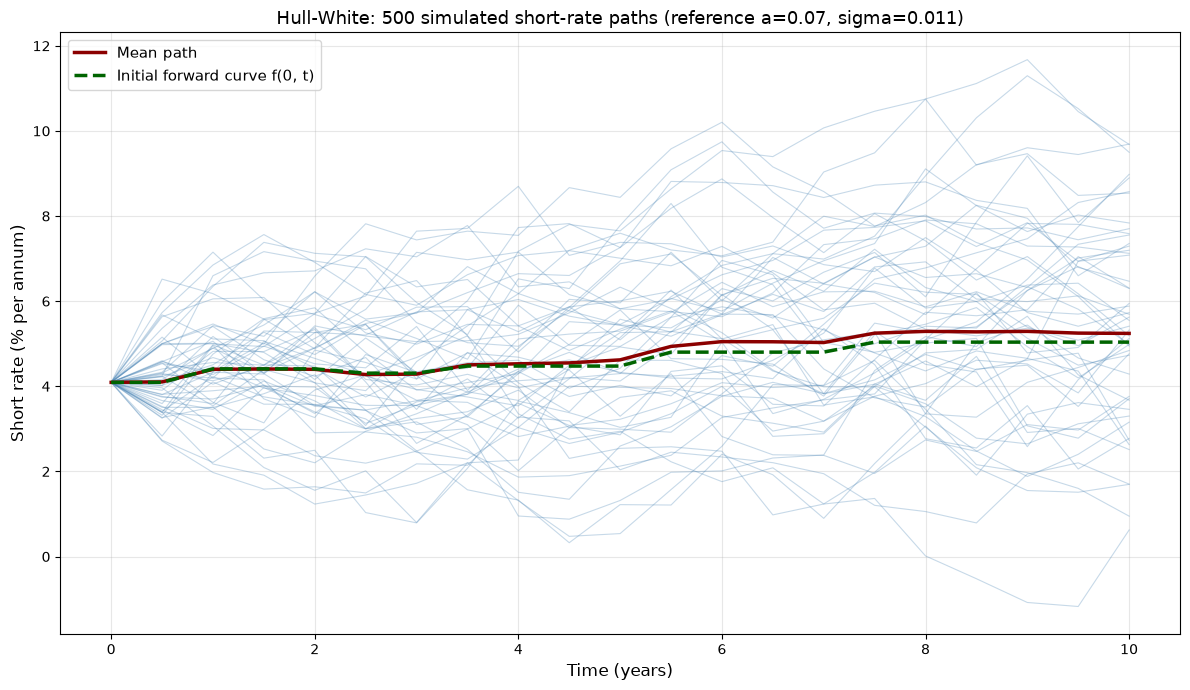

Path plot generated (50 sampled paths, mean path, initial forward curve).



In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

sample_indices = np.random.default_rng(SEED).choice(N_PATHS, size=50, replace=False)
for sample_idx in sample_indices:
    ax.plot(times, paths[sample_idx, :] * 100, alpha=0.3, linewidth=0.8, color="steelblue")

mean_path = paths.mean(axis=0) * 100
ax.plot(times, mean_path, color="darkred", linewidth=2.5, label="Mean path", zorder=10)

initial_forwards = np.array([hw_ref.instantaneous_fwd(t) for t in times]) * 100
ax.plot(
    times,
    initial_forwards,
    color="darkgreen",
    linewidth=2.5,
    linestyle="--",
    label="Initial forward curve f(0, t)",
    zorder=10,
)

ax.set_xlabel("Time (years)", fontsize=12)
ax.set_ylabel("Short rate (% per annum)", fontsize=12)
ax.set_title(
    "Hull-White: 500 simulated short-rate paths (reference a=0.07, sigma=0.011)",
    fontsize=13,
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Path plot generated (50 sampled paths, mean path, initial forward curve).")
print()

### Illustrative swaption volatility grid

The calibration target is the packaged illustrative grid
(`illustrative_swaption_vols.csv`): 28 ATM payer swaptions on 7 expiries
(0.5y, 1y, 2y, 3y, 5y, 7y, 10y) by 4 swap tenors (1y, 2y, 5y, 10y), with
normal volatilities in bp constructed from the deterministic formula in
`scripts/build_illustrative_vols.py`. The grid is **constructed, not
observed** (classified *illustrative* in the snapshot manifest; it is not
CME cleared-swaption settlement data, which requires a CME Information
License Agreement and is not redistributable here). The same grid feeds
the Streamlit app's calibration tab, so the numbers below agree with what
the app displays.

In [6]:
swaptions, market_vols = atm_swaption_grid(
    snapshot, ASOF, curve, dataset="illustrative_swaption_vols"
)

print("ILLUSTRATIVE SWAPTION GRID (constructed, not market data)")
print("-" * 70)
for s, v in zip(swaptions, market_vols, strict=True):
    exp_y = (s.expiry - ASOF).days / 365.25
    mat_y = (s.swap.maturity - s.expiry).days / 365.25
    print(f"  {exp_y:>4.1f}y x {mat_y:>4.1f}y: normal vol = {v * 1e4:>7.2f} bp")
print(f"  Total instruments: {len(swaptions)} (7 expiries x 4 tenors)")
print()

ILLUSTRATIVE SWAPTION GRID (constructed, not market data)
----------------------------------------------------------------------
   0.5y x  1.0y: normal vol =   79.97 bp
   0.5y x  2.0y: normal vol =   78.55 bp
   0.5y x  5.0y: normal vol =   74.42 bp
   0.5y x 10.0y: normal vol =   68.01 bp
   1.0y x  1.0y: normal vol =   89.09 bp
   1.0y x  2.0y: normal vol =   87.50 bp
   1.0y x  5.0y: normal vol =   82.90 bp
   1.0y x 10.0y: normal vol =   75.76 bp
   2.0y x  1.0y: normal vol =   89.89 bp
   2.0y x  2.0y: normal vol =   88.29 bp
   2.0y x  5.0y: normal vol =   83.65 bp
   2.0y x 10.0y: normal vol =   76.45 bp
   3.0y x  1.0y: normal vol =   82.78 bp
   3.0y x  2.0y: normal vol =   81.30 bp
   3.0y x  5.0y: normal vol =   77.03 bp
   3.0y x 10.0y: normal vol =   70.40 bp
   5.0y x  1.0y: normal vol =   69.41 bp
   5.0y x  2.0y: normal vol =   68.17 bp
   5.0y x  5.0y: normal vol =   64.58 bp
   5.0y x 10.0y: normal vol =   59.03 bp
   7.0y x  1.0y: normal vol =   62.80 bp
   7.0y x 

### Calibration to the illustrative grid (with diagnostics)

`calibrate` fits $(a, \sigma)$ by least squares in normal-volatility
space, minimising the root-mean-square error in volatility basis points:

$$\text{RMSE}_{vol,bp} = 10^4 \cdot \sqrt{\frac{1}{n}\sum_{i=1}^{n}
\left(\text{Model Vol}_i - \text{Grid Vol}_i\right)^2}$$

The grid is constructed from a smooth formula that a two-parameter
one-factor model cannot reproduce exactly, so the residuals below are real
and informative: they show what a genuine fit looks like. Every successful
fit also reports the optimizer status, whether either parameter sits on a
bound, the Jacobian rank and condition number, the residual scale, and the
start sensitivity (largest relative parameter move when refitting from
perturbed starting points). Boundary, rank-deficient, and start-sensitive
fits are rejected by `calibrate`, so a returned result has passed all of
those gates.

In [7]:
print("SWAPTION CALIBRATION (illustrative grid)")
print("-" * 70)

result = calibrate(curve, swaptions, market_vols, ASOF)

print("Calibrated parameters:")
print(f"  a (mean reversion, 1/yr):       {result.a:.6f}")
print(f"  sigma (volatility, 1/sqrt(yr)): {result.sigma:.6f}")
print()
print("Fit quality:")
print(f"  Instruments:                    {result.n_instruments}")
print(f"  RMSE (volatility bp):           {result.rmse_vol_bp:.4f}")
print()
print("Optimizer and identification diagnostics:")
print(f"  Optimizer success:              {result.success}")
print(f"  Active bounds (a, sigma):       {result.active_bounds}")
print(f"  Jacobian rank:                  {result.jacobian_rank} of 2 parameters")
print(f"  Jacobian condition number:      {result.jacobian_condition:.3f}")
print(f"  Residual scale (decimal vol):   {result.residual_scale:.3e}")
print(f"  Start sensitivity (limit 0.25): {result.start_sensitivity:.3e}")
print()
print(f"Implied half-life ln(2)/a:        {np.log(2.0) / result.a:.2f} years")
print()

SWAPTION CALIBRATION (illustrative grid)
----------------------------------------------------------------------


Calibrated parameters:
  a (mean reversion, 1/yr):       0.065716
  sigma (volatility, 1/sqrt(yr)): 0.008957

Fit quality:
  Instruments:                    28
  RMSE (volatility bp):           6.5026

Optimizer and identification diagnostics:
  Optimizer success:              True
  Active bounds (a, sigma):       (False, False)
  Jacobian rank:                  2 of 2 parameters
  Jacobian condition number:      63.826
  Residual scale (decimal vol):   6.503e-04
  Start sensitivity (limit 0.25): 2.581e-05

Implied half-life ln(2)/a:        10.55 years



Per-instrument residuals (model vol minus grid vol) in basis points.

In [8]:
model_vols_bp = np.array(result.model_vols) * 1e4
market_vols_bp = np.array(result.market_vols) * 1e4
residuals_bp = model_vols_bp - market_vols_bp

# Calibrated model, used for the negative-rate computation below
hw_cal = HullWhite(curve=curve, a=result.a, sigma=result.sigma)

print("CALIBRATION RESIDUALS (model vol - grid vol, bp)")
print("-" * 70)
print("Expiry (y) | Tenor (y) | Grid (bp) | Model (bp) | Residual (bp)")
print("-" * 70)
for i, (swapt, resid) in enumerate(zip(swaptions, residuals_bp, strict=True)):
    exp_y = (swapt.expiry - ASOF).days / 365.25
    mat_y = (swapt.swap.maturity - swapt.expiry).days / 365.25
    print(
        f"{exp_y:>10.1f} | {mat_y:>9.1f} | {market_vols_bp[i]:>9.2f} | "
        f"{model_vols_bp[i]:>10.2f} | {resid:>13.2f}"
    )
print("-" * 70)
print(f"RMS residual:                                {result.rmse_vol_bp:>13.4f}")
print(f"Max absolute residual:                       {np.abs(residuals_bp).max():>13.2f}")
print()

CALIBRATION RESIDUALS (model vol - grid vol, bp)
----------------------------------------------------------------------
Expiry (y) | Tenor (y) | Grid (bp) | Model (bp) | Residual (bp)
----------------------------------------------------------------------
       0.5 |       1.0 |     79.97 |      91.29 |         11.32
       0.5 |       2.0 |     78.55 |      84.60 |          6.06
       0.5 |       5.0 |     74.42 |      77.17 |          2.76
       0.5 |      10.0 |     68.01 |      67.23 |         -0.78
       1.0 |       1.0 |     89.09 |      87.63 |         -1.46
       1.0 |       2.0 |     87.50 |      83.30 |         -4.19
       1.0 |       5.0 |     82.90 |      76.00 |         -6.90
       1.0 |      10.0 |     75.76 |      66.14 |         -9.62
       2.0 |       1.0 |     89.89 |      83.09 |         -6.80
       2.0 |       2.0 |     88.29 |      80.49 |         -7.80
       2.0 |       5.0 |     83.65 |      73.93 |         -9.72
       2.0 |      10.0 |     76.45 |     

**Interpretation:** the fit converges with the RMSE and residuals printed
above (about 6.5 bp RMSE, 12.3 bp maximum). The misses carry both signs
and span the grid — from +11.3 bp at 0.5y x 1y to -12.3 bp at 2y x 10y —
because a two-parameter model trades off level against shape and cannot
reproduce a surface; this is the reason desks reach for two-factor or
local-volatility models in production. Nothing here is fitted to observed
market prices: the target grid is constructed, the residuals are a property
of the model type against that grid, and the diagnostics are the
identification evidence for the fit.

The fitted mean reversion $a \approx 0.066$ (printed above) implies a
half-life of about 10.5 years, so a shock to the short rate decays only
slowly over the simulated horizon. That figure is a property of the
illustrative grid, not an empirical estimate.

### Negative-rate probability from the conditional distribution

We compute the model-implied probability that the short rate is negative
at key horizons, from the conditional distribution of the *fitted* model:

$$Q\{r(t) < 0\} = \Phi\!\left(\frac{0 - E[r(t)\mid\mathcal{F}_0]}{\operatorname{SD}[r(t)\mid\mathcal{F}_0]}\right)$$  # noqa: E501

with the conditional mean `conditional_mean(0, t, r0)` (equal to
$\alpha(t)$) and the conditional standard deviation `conditional_sd(0, t)`
from the module — the same distribution that defines the simulated
transition. Using the raw instantaneous forward $f(0,t)$ in place of the
conditional mean would drop the convexity adjustment
$\sigma^2(1-e^{-at})^2/(2a^2)$ and bias the probability; the computation
below uses the model distribution itself.

In [9]:
horizons = np.array([1.0, 3.0, 5.0, 10.0])
negative_rate_probs = []

print("NEGATIVE-RATE PROBABILITY (from the fitted model's conditional distribution)")
print("-" * 70)
print("Horizon (y) | Cond. mean (%) | Cond. SD (%) | z-score  | P(r<0) (%)")
print("-" * 70)

for horizon in horizons:
    cond_mean = hw_cal.conditional_mean(0.0, horizon, hw_cal.r0)
    cond_sd = hw_cal.conditional_sd(0.0, horizon)
    z_score = (0.0 - cond_mean) / cond_sd
    prob_negative = norm.cdf(z_score)
    negative_rate_probs.append(prob_negative)
    print(
        f"{horizon:>11.1f} | {cond_mean * 100:>13.4f} | {cond_sd * 100:>12.4f} "
        f"| {z_score:>8.3f} | {prob_negative * 100:>10.4f}"
    )

print("-" * 70)
print()
print("These are model-implied probabilities under the fitted parameters and")
print("the Gaussian assumption — an exhibit for the model, not an empirical")
print("forecast. They rise with the horizon as the conditional variance")
print("grows, and stay small because the fitted forward curve is far from")
print("zero over this horizon. The same Gaussian property that produces them")
print("is also the reason the model prices bonds and swaptions in closed")
print("form.")
print()

NEGATIVE-RATE PROBABILITY (from the fitted model's conditional distribution)
----------------------------------------------------------------------
Horizon (y) | Cond. mean (%) | Cond. SD (%) | z-score  | P(r<0) (%)
----------------------------------------------------------------------
        1.0 |        4.4134 |       0.8670 |   -5.090 |     0.0000
        3.0 |        4.3386 |       1.4103 |   -3.076 |     0.1047
        5.0 |        4.5481 |       1.7146 |   -2.653 |     0.3995
       10.0 |        5.2533 |       2.1128 |   -2.486 |     0.6451
----------------------------------------------------------------------

These are model-implied probabilities under the fitted parameters and
the Gaussian assumption — an exhibit for the model, not an empirical
forecast. They rise with the horizon as the conditional variance
grows, and stay small because the fitted forward curve is far from
zero over this horizon. The same Gaussian property that produces them
is also the reason the model pri

## Interpretation

### Fit quality

The calibrated model is a one-factor Gaussian specification with two free
parameters. Against the 28-instrument illustrative grid it achieves the
RMSE printed above, with the misses concentrated at the short expiries —
the residual pattern of a two-parameter model spanning a surface it cannot
represent. The diagnostics (optimizer success, active bounds, Jacobian
rank/condition, residual scale, start sensitivity) are reported because a
least-squares result without them is not an identified fit.

### Path realism and negative rates

- **Mean reversion:** sampled paths that deviate from the conditional mean
  decay back toward $\alpha(t)$ at rate $e^{-at}$.
- **Variance saturation:** the conditional standard deviation grows with
  the horizon and saturates at $\sigma / \sqrt{2a}$ as $t \to \infty$.
- **Negative-rate probability:** model-implied, from the conditional
  distribution, small under the fitted parameters, and — like everything
  in this notebook — an educational exhibit rather than a market forecast.

None of this makes the model suitable for XVA, counterparty exposure, or
stress-testing work: those uses are out of scope for the reasons in the
Limitations section.

## Limitations

1. **Gaussian short rate:** negative rates carry strictly positive
   probability at every horizon (computed above). Whether that is a
   problem depends on the instrument and jurisdiction; shifted variants
   (e.g. shifted Hull-White) can enforce positivity at the cost of
   analytic tractability.

2. **Single factor:** every forward rate is driven by the same Brownian
   motion, so model-implied instantaneous correlations across the curve
   are all 1. The model is not used to generate curve scenarios in this
   repository (those come from the EU 2024/856 shock shapes), and PCA of
   historical moves shows more than one component.

3. **Two parameters cannot fit a volatility surface:** $(a, \sigma)$ span
   level and shape along one dimension; the smile across strikes and the
   full expiry-tenor grid are not captured. The packaged grid is ATM only,
   and no off-ATM error bound is claimed or measured.

4. **Illustrative calibration target:** the grid is constructed, not
   observed (see Data). The fitted $(a, \sigma)$ describe the grid, not a
   market. On real quotes, residuals would be larger, with bid-ask and
   microstructure noise on top of the model miss.

5. **Static parameters:** $(a, \sigma)$ are fitted once, over the whole
   grid. Real surfaces move; a production workflow would re-fit on a
   rolling basis, which this notebook does not do.

6. **Time discretisation:** the short rate itself is sampled exactly, but
   path discount factors use trapezoid quadrature on a monthly grid — an
   $O(h^2)$ approximation whose bias is measured in the module's time-step
   tests (about $2.9 \times 10^{-7}$ on the packaged fixture), not assumed
   away.

The full list, with quantified magnitudes, is in
`docs/hull-white-limitations.md`.

## Summary

This notebook walked through the one-factor Hull-White model as an
educational example:

- the complete affine bond formula, including the state term
  $e^{-B(t,T)r(t)}$, as implemented in `HullWhite.zcb`;
- a regression check that the affine price at time 0 reproduces the input
  discount curve to floating-point precision (an identity of the
  construction, not a fit);
- 500 exactly-sampled short-rate paths whose sample mean and standard
  deviation are printed against the analytic conditional moments, with the
  differences shown;
- a monthly path-discount approximation whose sample mean is printed
  against the exact analytic bond price, with the $O(h^2)$ trapezoid bias
  stated rather than hidden;
- a least-squares fit of $(a, \sigma)$ to the packaged illustrative grid,
  with full identification diagnostics and honest residuals (about 6.5 bp
  RMSE on a grid a two-parameter model cannot span);
- negative-rate probabilities from the fitted model's conditional
  distribution (about 0.00%, 0.10%, 0.40%, 0.65% at 1/3/5/10 years).

The exercise demonstrates the workflow — state the model, verify the
implementation, fit, report diagnostics, state limitations. It does not
demonstrate a production pricing or risk model, and the repository does
not present it as one.